In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
import sys
import os
sys.path.append(os.path.abspath('../utils'))

from ClusterAlgorithms import ClusterBy
from ClusterAlgorithms import k_LE_SC
from USA_Plot import plot_USA_Boundary

In [4]:
# Load the migration data MIG.csv and coordinates Coord.csv
df_A = pd.read_csv('MIG.csv',index_col=0)
print("Shape:", df_A.shape)
# Construct directed graph adjacency matrix
Ad = sparse.csr_matrix(df_A.values)

Shape: (3074, 3074)


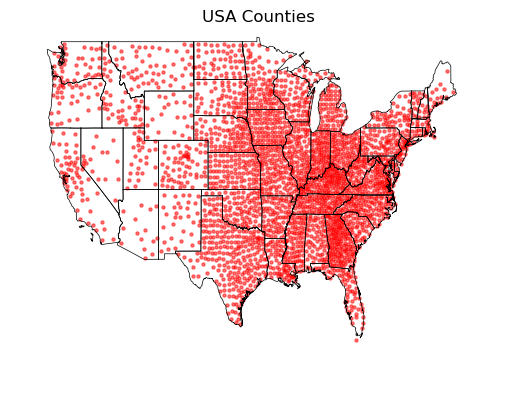

In [5]:
# Load the coordinates of the counties from Coord.csv
df_coords = pd.read_csv('Coord.csv')
county_coords = pd.read_csv('Coord.csv')
longitude = county_coords.iloc[:, 0]
latitude = county_coords.iloc[:, 1]
# Plot the USA boundary 
plot_USA_Boundary(LW=0.5) 
# Plot county coordinates
plt.scatter(longitude, latitude, s=5, c='red', alpha=0.5, label='Counties')
plt.title('USA Counties')
plt.axis('off')
plt.show()


In [ ]:
k = 3   # Number of clusters
N = Ad.shape[0]
# Data pre-processing: normalize the adjacency matrix by degree
P = np.sum(Ad,axis = 1)
O = np.sum(Ad,axis = 0)
O = np.array(O).flatten()
P = np.array(P).flatten()
A_norm = np.diag(1.0 / np.sqrt(O+P)) @ Ad @ np.diag(1.0 / np.sqrt(P+O))
A_test = A_norm

# Clustering with different methods
GCluster = ClusterBy(A_test, k)
y_Herm = GCluster.HermCLuster()
y_Sym = GCluster.SpectralCluster()
y_BibSym = GCluster.BibSym()
y_DISIM_L, y_DISIM_R = GCluster.DISIM(reg=1)
y_DSCORE = GCluster.DSCORE()
y_SimpHerm = GCluster.SimpHerm()
# Our method: iterative LE_SC
y_k_LE_SC = k_LE_SC(A_test, k, max_iter=10, init='Bal', t=0.05)


Iterative LE-SC converged within 5 iterations.
Iterative LE-SC converged within 3 iterations.


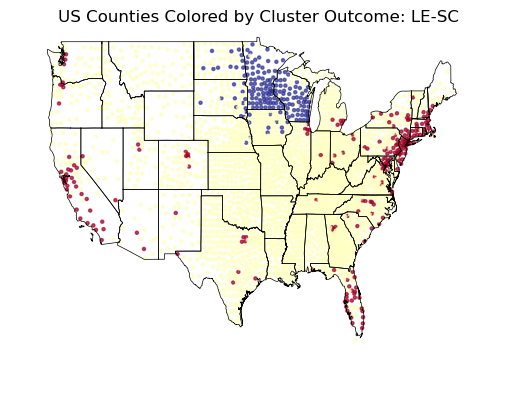

In [ ]:
# Plot the USA boundary
plot_USA_Boundary(LW=0.5)
# Scatter plot with color coding
plt.scatter(longitude, latitude, s=5, c=y_k_LE_SC, cmap='RdYlBu', alpha=0.7)
plt.title('US Counties Colored by Cluster Outcome: LE-SC')
plt.axis('off')
plt.show()


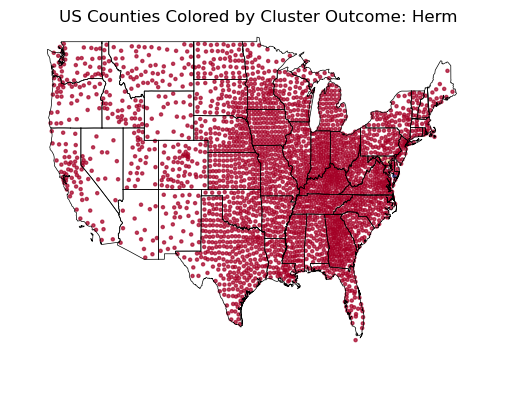

In [ ]:

# Ensure y_Herm has the same length as coordinates
if len(y_Herm) != len(longitude):
    raise ValueError("Length of y_Herm does not match the number of coordinates.")
# Plot the USA boundary
plt.figure()
plot_USA_Boundary(LW=0.5)
# Scatter plot with color coding
plt.scatter(longitude, latitude, s=5, c=y_Herm, cmap='RdYlBu', alpha=0.7) 
plt.title('US Counties Colored by Cluster Outcome: Herm')
plt.axis('off')
plt.show()


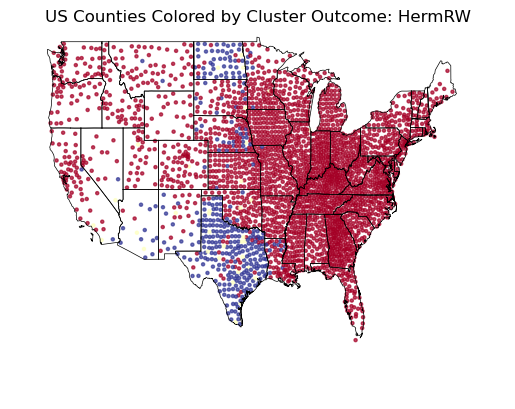

In [ ]:
# Plot the USA boundary
GClusterRW = ClusterBy(Ad, k)
y_HermRW = GClusterRW.HermRWCluster()
plt.figure()
plot_USA_Boundary(LW=0.5)
# Scatter plot with color coding
plt.scatter(longitude, latitude, s=5, c=y_HermRW, cmap='RdYlBu', alpha=0.7)
plt.title('US Counties Colored by Cluster Outcome: HermRW')
plt.axis('off')
plt.show()


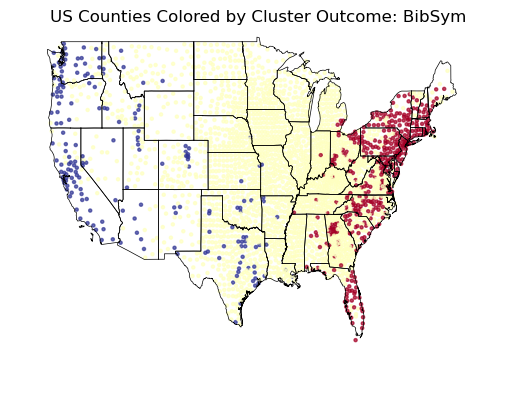

In [ ]:
# Plot the USA boundary
plot_USA_Boundary(LW=0.5)

# Scatter plot with color coding
plt.scatter(longitude, latitude, s=5, c=y_BibSym, cmap='RdYlBu', alpha=0.7) 
plt.title('US Counties Colored by Cluster Outcome: BibSym')
plt.axis('off')
plt.show()


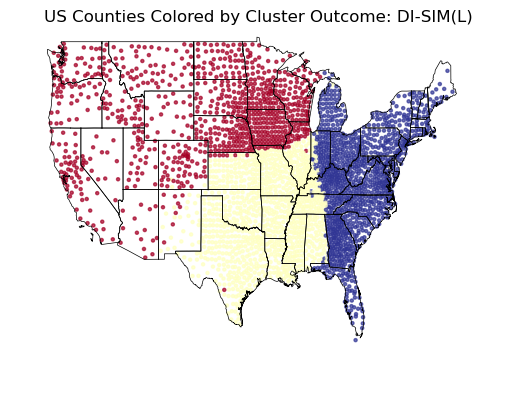

In [ ]:
# Plot the USA boundary
plot_USA_Boundary(LW=0.5)
# Scatter plot with color coding
plt.scatter(longitude, latitude, s=5, c=y_DISIM_L, cmap='RdYlBu', alpha=0.7) 
plt.title('US Counties Colored by Cluster Outcome: DI-SIM(L)')
plt.axis('off')
plt.show()


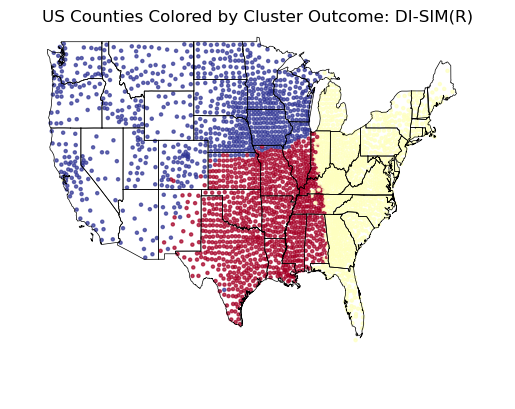

In [ ]:
# Plot the USA boundary
plot_USA_Boundary(LW=0.5)
# Scatter plot with color coding
plt.scatter(longitude, latitude, s=5, c=y_DISIM_R, cmap='RdYlBu', alpha=0.7)
plt.title('US Counties Colored by Cluster Outcome: DI-SIM(R)')
plt.axis('off')
plt.show()


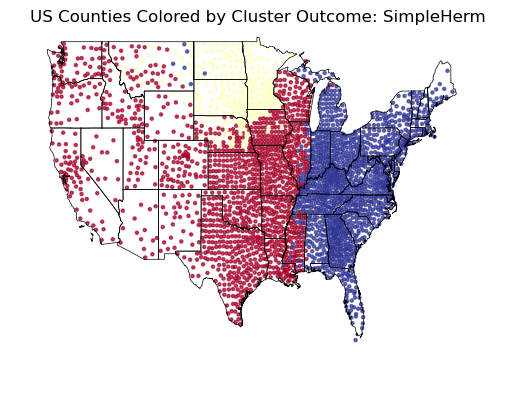

In [ ]:
# Plot the USA boundary
plot_USA_Boundary(LW=0.5)

# Scatter plot with color coding
plt.scatter(longitude, latitude, s=5, c=y_SimpHerm, cmap='RdYlBu', alpha=0.7) 
plt.title('US Counties Colored by Cluster Outcome: SimpleHerm')
plt.axis('off')
plt.show()


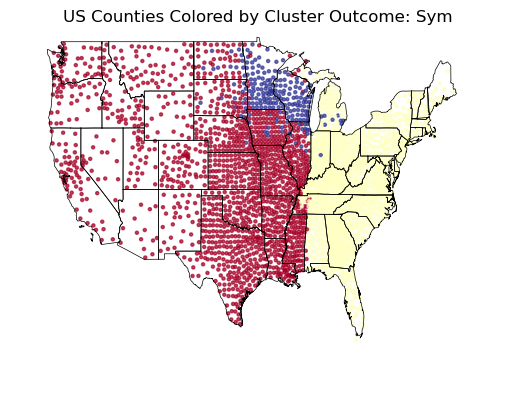

In [ ]:

# Plot the USA boundary
plot_USA_Boundary(LW=0.5)

# Scatter plot with color coding
plt.scatter(longitude, latitude, s=5, c=y_Sym, cmap='RdYlBu', alpha=0.7) 
plt.title('US Counties Colored by Cluster Outcome: Sym')
plt.axis('off')

plt.show()


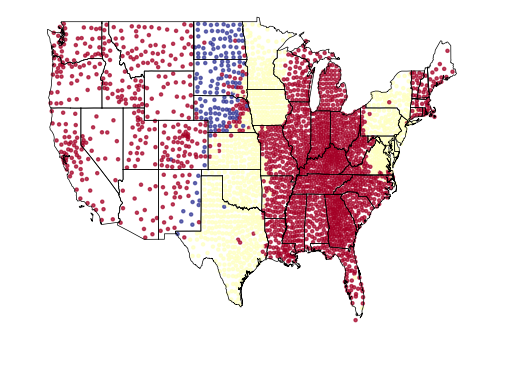

In [ ]:

# Plot the USA boundary
plot_USA_Boundary(LW=0.5)
# Scatter plot with color coding
plt.scatter(longitude, latitude, s=5, c=y_DSCORE, cmap='RdYlBu', alpha=0.7) 
# plt.title('US Counties Colored by Cluster Outcome: D-Score')
plt.axis('off')
plt.show()
